<a href="https://colab.research.google.com/github/mate-teglas/Introduction-to-machine-learning---Final-Project---TM-NZS-/blob/main/gender-classification_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This file is ran in google colab, since tensorflow would need an older python
# environment to be able to use a gpu on windows
# Also we work on different os, one solution that works on windows might not work on mac
# and thus we reached the conclusion that we should use either google colab or kaggle

# Drive folder location: https://drive.google.com/drive/folders/1KssUFsJxTkS7qAYOACIzuHAcQmMzO8xU?usp=drive_link

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt

In [4]:
# Mount to the drive of the one who runs the code, must conatain "IML/Training.zip & Validation.zip" to function
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Unzip training data
!unzip -q "/content/drive/MyDrive/IML/Training.zip" -d "/content/dataset/"

# Unzip validation data
!unzip -q "/content/drive/MyDrive/IML/Validation.zip" -d "/content/dataset/"

replace /content/dataset/Training/female/131422.jpg.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
replace /content/dataset/Validation/female/112944.jpg.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: All


In [6]:

# create batches of size 32 and resize to (256, 256)
train_dataset= keras.utils.image_dataset_from_directory(
    directory= '/content/dataset/Training',
    labels= 'inferred',
    label_mode = 'int',
    batch_size= 32,
    image_size = (256,256)
)


valid_dataset= keras.utils.image_dataset_from_directory(
    directory= '/content/dataset/Validation',
    labels= 'inferred',
    label_mode = 'int',
    batch_size= 32,
    image_size = (256,256)
)

Found 47009 files belonging to 2 classes.
Found 11649 files belonging to 2 classes.


In [ ]:
# Normalisation of data, cast to float32 (instead of 64?)

def process(image,label):
    image=tf.cast(image/255. , tf.float32)
    return image, label

train_dataset=train_dataset.map(process)
valid_dataset=valid_dataset.map(process)

In [7]:

# Increasing number of filters of sequential Conv2D for more and more complex features
model = Sequential()

# 1st 2D convolution part
model.add(Conv2D(32, kernel_size=(2,2),padding='valid',activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

# 2nd 2D convolution part
model.add(Conv2D(64, kernel_size=(2,2),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

# 3rd 2D convolution part
model.add(Conv2D(128, kernel_size=(2,2),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

# create a 1D vector usable by the Dense layer
model.add(Flatten())

# Gradually decrease the dim and focus on more important features this way
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

# Show the model layers
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 255, 255, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 255, 255, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 64)   │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 62, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 123008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    15,745,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,795,937 (60.26 MB)

 Trainable params: 15,795,489 (60.26 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [9]:
# train
history= model.fit(train_dataset, epochs=10, validation_data=valid_dataset)

Epoch 1/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 125s 79ms/step - accuracy: 0.8675 - loss: 0.5547 - val_accuracy: 0.8757 - val_loss: 0.2730
Epoch 2/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - accuracy: 0.9253 - loss: 0.1970 - val_accuracy: 0.9287 - val_loss: 0.1879
Epoch 3/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - accuracy: 0.9376 - loss: 0.1678 - val_accuracy: 0.9252 - val_loss: 0.2037
Epoch 4/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 143s 79ms/step - accuracy: 0.9483 - loss: 0.1423 - val_accuracy: 0.9129 - val_loss: 0.2216
Epoch 5/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 141s 78ms/step - accuracy: 0.9548 - loss: 0.1216 - val_accuracy: 0.9060 - val_loss: 0.2332
Epoch 6/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 141s 78ms/step - accuracy: 0.9616 - loss: 0.1032 - val_accuracy: 0.9226 - val_loss: 0.2050
Epoch 7/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - accuracy: 0.9698 - loss: 0.0831 - val_accuracy: 0.9335 - val_loss: 0.1661
Epoch 8/10
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - accuracy: 

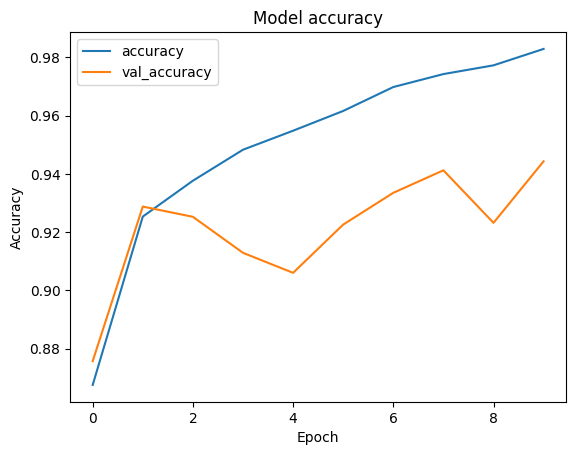

In [10]:
# plot accuracy
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [11]:
# Save the model
model.save('/content/drive/MyDrive/IML/gender_classification_epoch_10.keras')